# AP 155 Lab Exercise
---
## Exercise 3: Numbers | Horner's method

_Instructions_:
- **Report discussion:** Address the following prompts.
    - Compare the rounding error patterns and output stability of Horner's method versus the naive power evaluation.
    - Explain why algebraically identical expressions (e.g., the two expressions of polynomials in problem 1, or the three ways we expressed the same function in problem 2) produce different numerical values when implemented in floating-point arithmetic.
    - Discuss how algorithmic redesign (such as Horner's rule or expression restructuring) mitigates floating-point error accumulation.
- **Report figure (to be reflected in code) (Problem 2):** Create a $2 \times 3$ grid of subplots comparing evaluations of the rational function $r(x)$:
    - Columns (3 Methods): Naive method (using direct powers), Horner's method, Rewritten form $s(x)$
    - Rows (2 values of $x$-points) $x= 1.606 + 2^{-52}$ and $2.400 + 2^{-52}i$ where $i\in[0,800]$.
  
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name_: Custodio, Neil Matthew
- _Student No._: 2024-14318
- _Section_: THR-TX-2

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 |
| Code appropriateness  | XX | 20 |
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Discussion

- **Report discussion:** Address the following prompts.
    - Compare the rounding error patterns and output stability of Horner's method versus the naive power evaluation.
      - The naive power evaluation calculates each power $x^i$ through redundant left-to-right multiplication which leads to rounding errors. Horner's method nests the multiplications which tightens the error bounds and lowers $O$ from $O(n^2)$ to $O(n)$.
    - Explain why algebraically identical expressions (e.g., the two expressions of polynomials in problem 1, or the three ways we expressed the same function in problem 2) produce different numerical values when implemented in floating-point arithmetic.
      - The differences in numerical values come from the precise nature of floating-point arithmethic. Every time an operation is performed a rounding error occurs. The naive method has redundant exponentiation which causes a higher error from the true value. Rewriting the function to avoid operations that cause higher/more complex error like what we did with Horner's and the simplified expression shows that mathematically equivalent expressions do not yield identical floating-point outcomes.
    - Discuss how algorithmic redesign (such as Horner's rule or expression restructuring) mitigates floating-point error accumulation.
      - Horner's rule and the expression restructuring mititigates the floating-point error accumulation by reducing complexity, skipping exponentiation/multiplcation operations, and preventing large-scale magnitude shifts that cause precision loss.

---

---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1:

This problem discussed error buildup when trying to evaluate polynomials without and with the use of *Horner's Rule*. Take a polynomial of degree $n-1$:
$$ P(x) = p_0 + p_1x + p_2x^2 + p_3x^3 + ... + p_{n-1}x^{n-1}. $$

Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the naive way, i.e. from left to right.

Notice that this way of coding up the polynomial contains several (needless) multiplications. This is so because $x^i$ is evaluated as $x\times x\times ... \times x$ (where there are $i-1$ multiplications). Thus, this way of approaching the problem corresponds to
$$ 1 + 2 + ... + n-2 = \frac{(n-1)(n-2)}{2}$$
multiplications, from $x^2$ all the way up to $x^{n-1}$.

Let `coeffs=[(-11)**i for i in reversed(range(8))]` and `x = 11.01`

In [2]:
coeffs= [(-11)**i for i in reversed(range(8))]
x = 11.01

In [17]:
def eval_naive(coeffsList, x):
  """evaluate naively from left to right, using the power/exponent operations"""
  xtot = []
  total = 0
  for i in range(len(coeffsList)):
    xtot = [x**y for y in range(len(coeffsList))]

  v = 0
  while v < len(coeffsList):
    total = total + coeffsList[v]*xtot[v]
    v += 1
  return total

eval_naive(coeffs, x)

71056.02362162992

If we write the polynomial:
$$ P(x) = p_0 + x(p_1 + x(p_2 + x(p_3 + ... + x(p_{n-2} + xp_{n-1})...))) \tag{1}$$

then we can get away with only $n-1$ multiplications (i.e., no powers are evaluated). This is obviously more efficient, but equally important is the fact that this way we can substantially limit the accumulation of rounding error (especially for polynomials of large degree).

Write a function that takes in a list containing the $p_i$'s, say `coeffs`  and the point $x$ and evaluates the value of $P(x)$ in a new way, i.e., from right to left.

In [4]:
coeffs= [(-11)**i for i in reversed(range(8))]
x = 11.01

In [18]:
def eval_horner(coeffsList, x):
    """using Horner's rule from right to left"""
    total = 0.0
    for p_i in reversed(coeffsList):
        total = total * x + p_i
    return total

eval_horner(coeffs, x)

71056.02362163365

Try timing the code and compare (Shift enter the next two cells)

In [19]:
%timeit eval_naive(coeffs, x) #call the horner's rule function here, then shift enter

8.35 µs ± 411 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [20]:
%timeit eval_horner(coeffs, x) #call the naive function here, then shift enter

965 ns ± 274 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


Apply the previous two functions to the (admittedly artificial) case of:
`coeffs=[(-11)**i for i in reversed(range(8))]` and $x=11.01$. Observe any discrepancy and discuss its origin.

In [22]:
naive_val = eval_naive(coeffs,x)
horner_val = eval_horner(coeffs,x)

print(f"Naive evaluation:   {naive_val}")
print(f"Horner's evaluation: {horner_val}")
print(f'Error: {abs(naive_val - horner_val)/max(naive_val, horner_val) * 100}%')

Naive evaluation:   71056.02362162992
Horner's evaluation: 71056.02362163365
Error: 5.242750872605424e-12%


Problem 1 code summary

The code compares naive polynomial evaulation against Horner's method. The naive approach goes through redundant power computations using left-to-right multiplication, this causes $O(n^2)$ complexity and increased error. Horner's method evaluates the polynomial from right to left using nested multiplications, which reduces the complexity to $O(n) and reduces error.

---

### Problem 2:

This problem studies the rational function introduced in the main text, Eq. (2.53).

$$ r(x) = \frac{4x^4 - 59x^3 + 324 x^2 - 751x + 622}{x^4 - 14x^3 + 72x^2 - 151x + 112} \tag{2}$$

(a) Apply Horner’s rule twice (once for the numerator and once for the denominator) to produce two plots, one for $x = 1.606 + 2^{−52}i$ and one for $x = 2.400 + 2^{−52}i$. Your results should look like Fig. 2.3.


- To replicate Figure 2.3, $i$ is an array from 0 to 800 with dtype np.float64
- This means $x$ should be an array as well

In [24]:
import matplotlib.pyplot as plt
import numpy as np

num_coeffs = [622, -751, 324, -59, 4]
den_coeffs = [112, -151, 72, -14, 1]

i = np.arange(0, 801, dtype=np.float64)

x1 = 1.606 + 2**(-52)*i
x2 = 2.400 + 2**(-52)*i

#We will use these variables for the rest of the code below

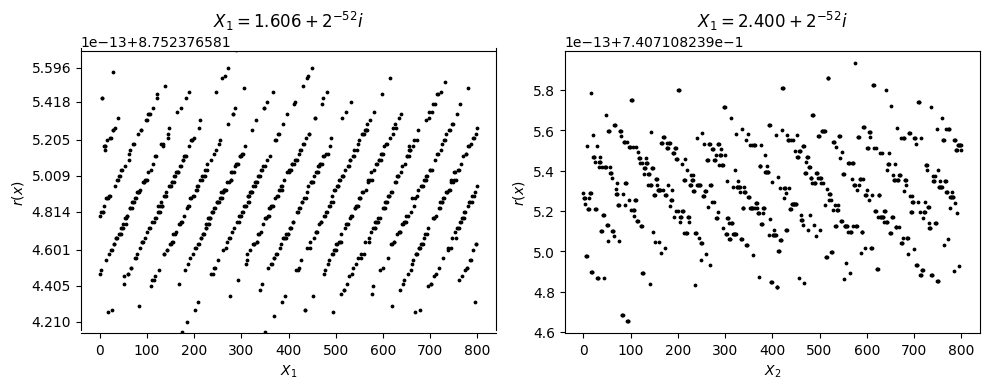

In [40]:
#Applying horner's rule in numerator and denominator
y1 = eval_horner(num_coeffs, x1) / eval_horner(den_coeffs, x1)
y2 = eval_horner(num_coeffs, x2) / eval_horner(den_coeffs, x2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10,4))

ax1.set_title("$X_1 = 1.606 + 2^{-52}i$")
ax1.scatter(i, y1, s=3, color="black")
ax1.set_xlabel('$X_1$')
ax1.set_ylabel('$r(x)$')
ax1.set_ylim(bottom=min(y1), top=max(y1))

ax2.set_title("$X_1 = 2.400 + 2^{-52}i$")
ax2.scatter(i, y2, s=3, color="black")
ax2.set_xlabel('$X_2$')
ax2.set_ylabel('$r(x)$')

plt.tight_layout()

#The output should look like figure 3.
#The y-axis could be confusing the but there's a number on top that ...
#...tells the order of magnitude and the offset of the tick marks on the y-axis

(b) Create a new Python function that codes up the following expression:
$$ s(x)= 4− \frac{3(x−2)[(x−5)^2 + 4]}{x + (x−2)^2[(x−5)^2 + 3]}$$
which is a rewritten version of our rational function. Apply this new function for
the previous two plots and compare the rounding error pattern, size, etc.

In [31]:
def s(x):
  num = 3 * (x-2) * ((x-5)**2 + 4)
  den = x + (x-2)**2 * ((x-5)**2 + 3)
  return 4 - (num/den)

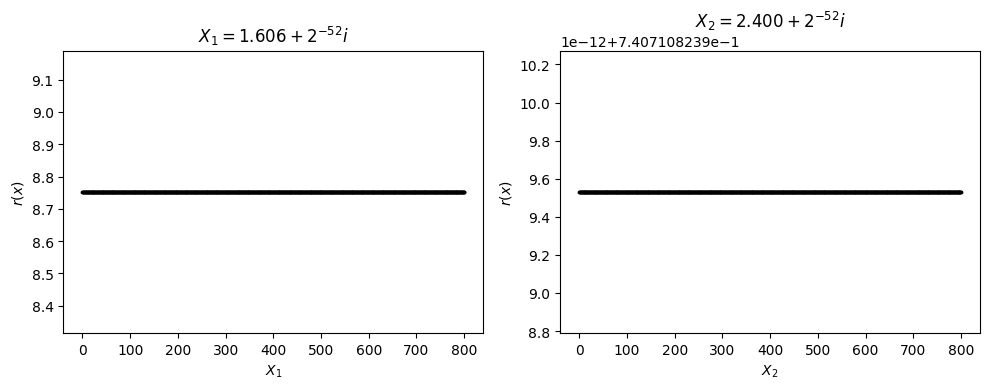

In [38]:

#using x1 and x2 from earlier
y1 = s(x1)#insert here
y2 = s(x2)#insert here

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10,4))

ax1.set_title("$X_1 = 1.606 + 2^{-52}i$")
ax1.scatter(i, y1, s=3, color="black")
ax1.set_xlabel('$X_1$')
ax1.set_ylabel('$r(x)$')
ax1.set_ylim(bottom=min(y1), top=max(y1))

ax2.set_title("$X_2 = 2.400 + 2^{-52}i$")
ax2.scatter(i, y2, s=3, color="black")
ax2.set_xlabel('$X_2$')
ax2.set_ylabel('$r(x)$')

plt.tight_layout()

(c) Now introduce two more sets of results, this time for the starting expression for $r(x)$ produced using (not Horner’s rule but) the naive implementation, using powers (i.e., the way you would have coded this up before doing problem 2.11).
Interpret your findings.

- Note: use the earlier function in problem 1 in the naive evaluation

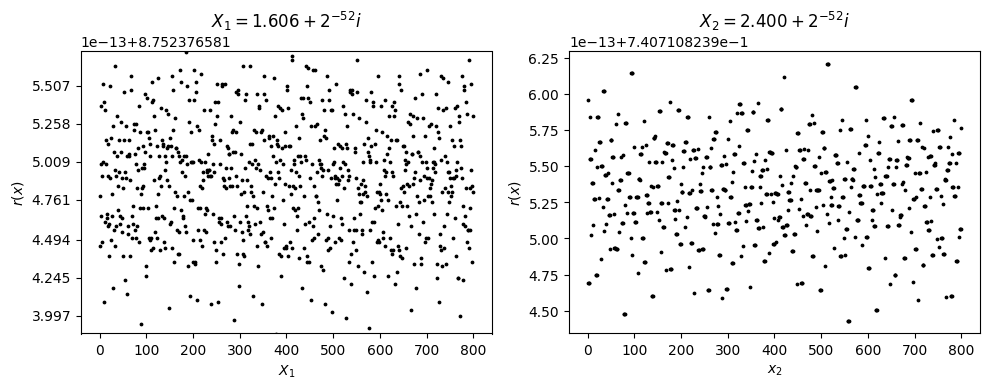

In [42]:
import matplotlib.pyplot as plt
import numpy as np

num_coeffs = [622, -751, 324, -59, 4]
den_coeffs = [112, -151, 72, -14, 1]

y1 = eval_naive(num_coeffs, x1)/eval_naive(den_coeffs, x1)
y2 = eval_naive(num_coeffs, x2)/eval_naive(den_coeffs, x2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10,4))

ax1.set_title("$X_1 = 1.606 + 2^{-52}i$")
ax1.scatter(i, y1, s=3, color="black")
ax1.set_xlabel('$X_1$')
ax1.set_ylabel('$r(x)$')
ax1.set_ylim(bottom=min(y1), top=max(y1))

ax2.set_title("$X_2 = 2.400 + 2^{-52}i$")
ax2.scatter(i, y2, s=3, color="black")
ax2.set_xlabel('$x_2$')
ax2.set_ylabel('$r(x)$')

plt.tight_layout()

Let's summarize all outputs (6 of them) into a 2 row by 3 column plot

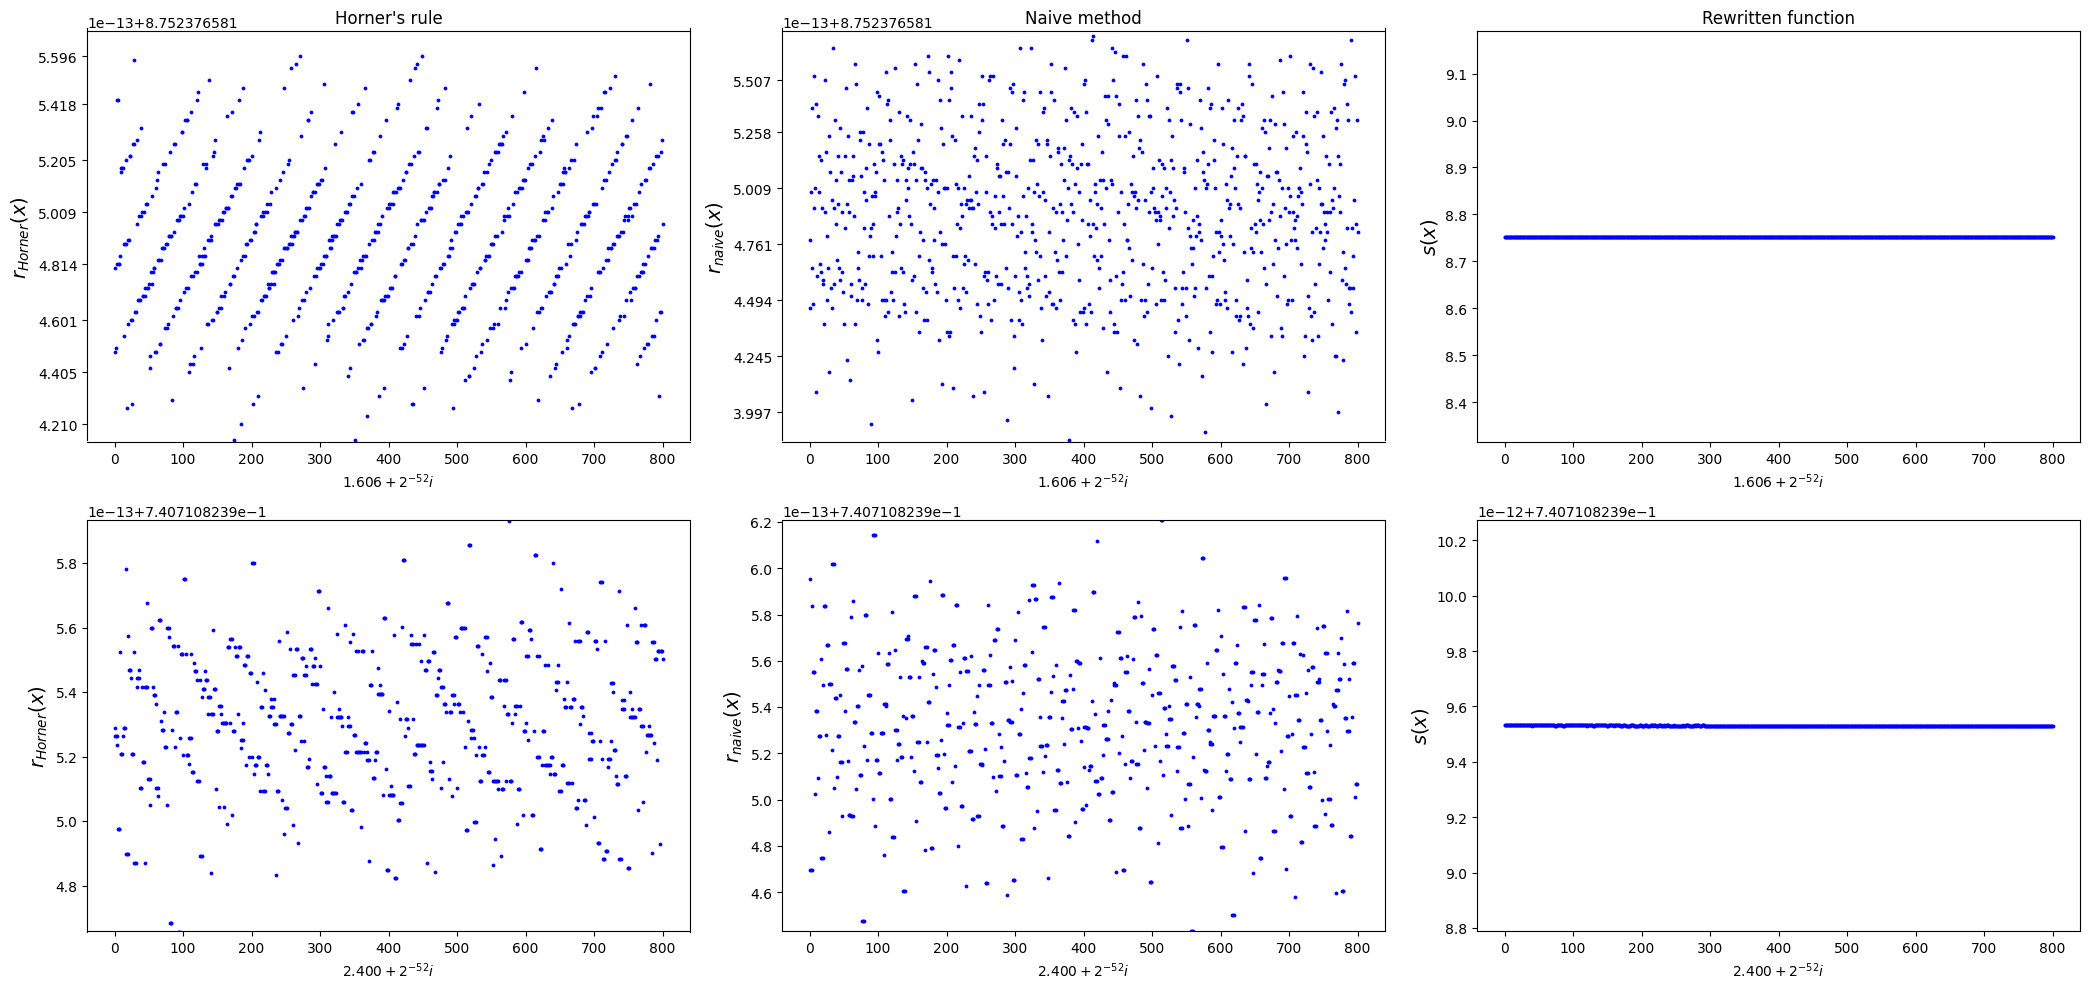

In [44]:
# summarize all subplots

#We use the previously defined variables of num_coeffs, den_coeffs, x1, x2, and i
#We use the previously defined functions of eval_horner, eval_naive, and s

y_horner_x1 = eval_horner(num_coeffs, x1) / eval_horner(den_coeffs, x1)
y_horner_x2 = eval_horner(num_coeffs, x2) / eval_horner(den_coeffs, x2)
y_naive_x1 = eval_naive(num_coeffs, x1)/eval_naive(den_coeffs, x1)
y_naive_x2 = eval_naive(num_coeffs, x2)/eval_naive(den_coeffs, x2)
y_good_x1 = s(x1)
y_good_x2 = s(x2)

arrays = [y_horner_x1, y_naive_x1, y_good_x1, y_horner_x2, y_naive_x2, y_good_x2]
y_min = np.min(arrays)
y_max = np.max(arrays)


fig, axs = plt.subplots(2, 3, figsize=(21, 10))

# Row 1: x = 1.606 + 2^-52 i
axs[0, 0].scatter(i, y_horner_x1, s=3, color="blue")
axs[0, 0].set_title("Horner's rule")
axs[0, 0].set_xlabel("$1.606 + 2^{-52}i$")
axs[0, 0].set_ylabel("$r_{Horner}(x)$", fontsize=14)
axs[0, 0].set_ylim(bottom=min(y_horner_x1), top=max(y_horner_x1))

axs[0, 1].scatter(i, y_naive_x1, s=3, color="blue")
axs[0, 1].set_title("Naive method")
axs[0, 1].set_xlabel("$1.606 + 2^{-52}i$")
axs[0, 1].set_ylabel("$r_{naive}(x)$", fontsize=14)
axs[0, 1].set_ylim(bottom=min(y_naive_x1), top=max(y_naive_x1))

axs[0, 2].scatter(i, y_good_x1, s=3, color="blue")
axs[0, 2].set_title("Rewritten function")
axs[0, 2].set_xlabel("$1.606 + 2^{-52}i$")
axs[0, 2].set_ylabel("$s(x)$", fontsize=14)
axs[0, 2].set_ylim(bottom=min(y_good_x1), top=max(y_good_x1))

# Row 2: x = 2.400 + 2^-52 i
axs[1, 0].scatter(i, y_horner_x2, s=3, color="blue")
axs[1, 0].set_xlabel("$2.400 + 2^{-52}i$")
axs[1, 0].set_ylabel("$r_{Horner}(x)$", fontsize=14)
axs[1, 0].set_ylim(bottom=min(y_horner_x2), top=max(y_horner_x2))

axs[1, 1].scatter(i, y_naive_x2, s=3, color="blue")
axs[1, 1].set_xlabel("$2.400 + 2^{-52}i$")
axs[1, 1].set_ylabel("$r_{naive}(x)$", fontsize=14)
axs[1, 1].set_ylim(bottom=min(y_naive_x2), top=max(y_naive_x2))

axs[1, 2].scatter(i, y_good_x2, s=3, color="blue")
axs[1, 2].set_xlabel("$2.400 + 2^{-52}i$")
axs[1, 2].set_ylabel("$s(x)$", fontsize=14)

plt.tight_layout()
plt.show()


#### Problem 2 code summary

The code evaluates the rational function $r(x)$ at different arrays of dx ($1.606 \times 2^{-52}i$ and $2.400 \times 2^{-52}i$ using Naive method, Horner's rule, and a simplified expression `s(x)`. The code uses numpy arrays to allow operations to be performed at once over the entire 800-element list. Using the performed operations an overall combined figure is produced to show visually the differences in the error and how each method changes the noise and distribution.

---